In [1]:
!pip install datasets seaborn
! pip install -U accelerate
! pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 82.5 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
from datasets import load_dataset
import pandas as pd
from datetime import datetime, timedelta
from tqdm.auto import tqdm
from collections import Counter

In [5]:
df = pd.read_excel("Normativa_con_resumenes.xlsx")

In [6]:
df.columns

Index(['Tipo', 'Número', 'Añosanción', 'texto completo', 'periodos',
       'periodos2', 'rango', 'presidencia', 'decadas', 'Título', 'Subtítulo',
       'Resumen', 'Artículos', 'caso_ok', 'caso', 'internacional_ok', 'tema',
       'subtema', 'tema2', 'subtema2', 'pol_ok1', 'pol_ok2', 'Comentarios',
       'texto_pdf', 'resumen_ocr'],
      dtype='object')

In [7]:
# nos quedamos solo con etiquetados
df = df[df["caso_ok"].notna()]

# texto final
df["texto"] = (
    df["Título"].fillna("") +" [SEP] "+ df["Resumen"].fillna("") +
    " [SEP] " + df["Artículos"].fillna("")+ " [SEP] " + df["resumen_ocr"].fillna("") +
    " [SEP] " + df["caso"].fillna("")
)

df = df[["texto", "caso_ok"]] # nos quedamos solo con las columnas necesarias

df["caso_ok"] = df["caso_ok"].astype(int)

print(df.head())

                                               texto  caso_ok
0  CODIGO CIVIL [SEP]  [SEP] ARTICULO 1079.- La o...        0
1  SUBSIDIO ESTATAL [SEP] AUTORIZA SUBSIDIO DESTI...        1
2  SUBSIDIO ESTATAL [SEP] SUBSIDIO A LAS VICTIMAS...        1
3  CODIGO PROCESAL PENAL DE LA NACION [SEP]  [SEP...        0
4  CODIGO DE COMERCIO [SEP]  [SEP] Art. 184. En c...        0


In [8]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["caso_ok"],
    random_state=42
)

In [9]:
df

,texto,caso_ok
0,CODIGO CIVIL [SEP] [SEP] ARTICULO 1079.- La o...,0
1,SUBSIDIO ESTATAL [SEP] AUTORIZA SUBSIDIO DESTI...,1
2,SUBSIDIO ESTATAL [SEP] SUBSIDIO A LAS VICTIMAS...,1
3,CODIGO PROCESAL PENAL DE LA NACION [SEP] [SEP...,0
4,CODIGO DE COMERCIO [SEP] [SEP] Art. 184. En c...,0
...,...,...
199,ACUERDOS [SEP] APRUEBASE EL “ACUERDO DE CUMPLI...,1
200,ACUERDOS [SEP] APRUEBASE EL ACUERDO DE SOLUCIO...,1
201,PROGRAMA MÉDICO OBLIGATORIO DE LAS OBRAS SOCIA...,0
202,CORTE INTERAMERICANA DE DERECHOS HUMANOS [SEP]...,1


In [10]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

In [11]:
from transformers import AutoTokenizer

model_name = "dccuchile/bert-base-spanish-wwm-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_data(examples):

    return tokenizer(
        examples["texto"],
        truncation=True,
        padding="max_length",
        max_length=500
    )

train_ds = train_ds.map(preprocess_data, batched=True)
test_ds = test_ds.map(preprocess_data, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Map:   0%|          | 0/142 [00:00<?, ? examples/s]

Map:   0%|          | 0/62 [00:00<?, ? examples/s]

In [12]:
train_ds = train_ds.rename_column("caso_ok", "labels")
test_ds = test_ds.rename_column("caso_ok", "labels")

In [13]:
train_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [14]:
id2label = {
    0: "NO_VICTIMAS",
    1: "VICTIMAS"
}

label2id = {
    "NO_VICTIMAS": 0,
    "VICTIMAS": 1
}

In [15]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

import numpy as np

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    # Accuracy
    accuracy = accuracy_score(labels, predictions)

    # F1 macro
    f1_macro = f1_score(
        labels,
        predictions,
        average="macro"
    )

    # F1 positivos (clase 1)
    f1_positivos = f1_score(
        labels,
        predictions,
        pos_label=1
    )

    # F1 negativos (clase 0)
    f1_negativos = f1_score(
        labels,
        predictions,
        pos_label=0
    )

    # Precision positivos
    precision_positivos = precision_score(
        labels,
        predictions,
        pos_label=1
    )

    # Recall positivos
    recall_positivos = recall_score(
        labels,
        predictions,
        pos_label=1
    )

    # Cohen Kappa
    kappa = cohen_kappa_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_positivos": f1_positivos,
        "f1_negativos": f1_negativos,
        "precision_positivos": precision_positivos,
        "recall_positivos": recall_positivos,
        "kappa": kappa
    }

In [18]:
from transformers import TrainingArguments

batch_size = 8

args = TrainingArguments(

    output_dir="./beto_victimas",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",

    report_to="none"
)

In [19]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=args,

    train_dataset=train_ds,
    eval_dataset=test_ds,

    compute_metrics=compute_metrics
)

In [20]:
trainer.train() #####DESDE ACA SEGUIR Y COMPARAR EN EL DOCUMENTO CON LOS OTROS VALORES

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Positivos,F1 Negativos,Precision Positivos,Recall Positivos,Kappa
1,No log,0.364634,0.870968,0.848225,0.789474,0.906977,1.000000,0.652174,0.702281
2,No log,0.260953,0.887097,0.872465,0.829268,0.915663,0.944444,0.739130,0.746791
3,No log,0.301560,0.903226,0.891986,0.857143,0.926829,0.947368,0.782609,0.784971
4,No log,0.233545,0.951613,0.946598,0.930233,0.962963,1.000000,0.869565,0.893471
5,No log,0.138539,0.967742,0.965440,0.956522,0.974359,0.956522,0.956522,0.930881


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=90, training_loss=0.16503694322374132, metrics={'train_runtime': 189.1842, 'train_samples_per_second': 3.753, 'train_steps_per_second': 0.476, 'total_flos': 182430516900000.0, 'train_loss': 0.16503694322374132, 'epoch': 5.0})

In [21]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Positivos,F1 Negativos,Precision Positivos,Recall Positivos,Kappa
No log,0.138539,5,0.967742,0.965440,0.956522,0.974359,0.956522,0.956522,0.930881


{'eval_loss': 0.1385394036769867, 'eval_accuracy': 0.967741935483871, 'eval_f1_macro': 0.9654403567447045, 'eval_f1_positivos': 0.9565217391304348, 'eval_f1_negativos': 0.9743589743589743, 'eval_precision_positivos': 0.9565217391304348, 'eval_recall_positivos': 0.9565217391304348, 'eval_kappa': 0.9308807134894092}


In [24]:
trainer.save_model("./modelo_beto_derechos_victimas")

tokenizer.save_pretrained("./modelo_beto_derechos_victimas")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./modelo_beto_derechos_victimas/tokenizer_config.json',
 './modelo_beto_derechos_victimas/tokenizer.json')

In [25]:
from transformers import pipeline

clf = pipeline(
    "text-classification",
    model="./modelo_beto_derechos_victimas",
    tokenizer="./modelo_beto_derechos_victimas"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [26]:
texto = """
Protección contra la violencia familiar.
Se crean centros de asesoramiento y asistencia jurídica gratuita.
"""

resultado = clf(texto)

print(resultado)

[{'label': 'NO_VICTIMAS', 'score': 0.96544349193573}]


In [31]:
predictions = trainer.predict(test_ds)

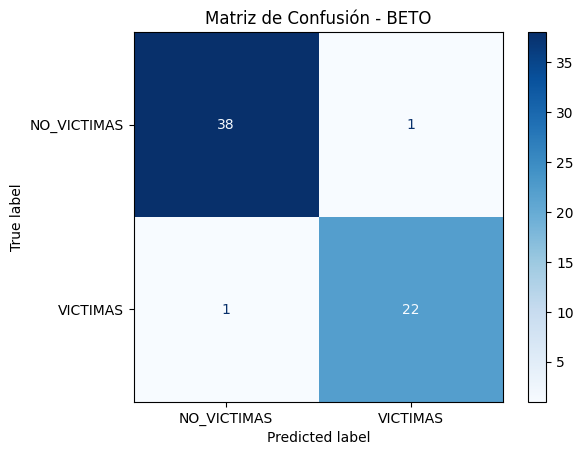

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NO_VICTIMAS", "VICTIMAS"]
)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusión - BETO")

plt.show()